# Graph Projection

This notebook loads the 20D business-cluster video embedding export from Drive, computes per-channel centroids, builds a channel adjacency graph from relative distances, and projects channels into a 2D layout for plotting.

This cell imports the libraries used for data loading, distance computation, graph construction, and visualization.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS

This cell mounts Google Drive (when running in Colab) and defines the documented export path for the 20D reduced video embeddings artifact.

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Colab Drive mount skipped (not running in Colab).')

EMBEDDINGS_CSV = Path('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv')
EMBEDDINGS_CSV

Mounted at /content/drive


PosixPath('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv')

This cell loads the 20D video embedding export and validates that the expected reduced embedding columns are present.

In [3]:
df = pd.read_csv(EMBEDDINGS_CSV)
embedding_cols = [f'embedding_reduced_{i:02d}' for i in range(1, 21)]
missing_cols = [c for c in embedding_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing embedding columns: {missing_cols}')

print(f'Rows: {len(df):,}')
print(f'Channels: {df["channel_id"].nunique():,}')
df[['video_id', 'channel_id', 'video_title'] + embedding_cols[:3]].head()

Rows: 1,344
Channels: 27


,video_id,channel_id,video_title,embedding_reduced_01,embedding_reduced_02,embedding_reduced_03
0,MIKej1HCRW0,UC-yRDvpR99LUc5l7i7jLzew,ChatGPT – The Super Assistant Era | BG2 Guest ...,-0.079211,-0.036029,0.055242
1,jA8ZQfq_Hzs,UC-yRDvpR99LUc5l7i7jLzew,AI Enterprise - Databricks & Glean | BG2 Guest...,-0.089886,-0.036546,0.047207
2,Gnl833wXRz0,UC-yRDvpR99LUc5l7i7jLzew,All things AI w @altcap @sama & @satyanadella....,-0.170729,-0.025156,0.126156
3,KX6q6lvoYtM,UC-yRDvpR99LUc5l7i7jLzew,"AI Bubble, Stablecoin Boom, and Runnin' Down a...",-0.175819,0.005687,0.065875
4,pE6sw_E9Gh0,UC-yRDvpR99LUc5l7i7jLzew,"NVIDIA: OpenAI, Future of Compute, and the Ame...",-0.199190,0.022858,0.094662


This cell computes a centroid per channel by averaging each channel's 20D video embeddings.

In [4]:
channel_centroids = (
    df.groupby('channel_id', as_index=False)[embedding_cols]
      .mean()
)

if 'channel_name' in df.columns:
    channel_labels = (
        df[['channel_id', 'channel_name']]
        .dropna(subset=['channel_id'])
        .drop_duplicates(subset=['channel_id'])
    )
    channel_centroids = channel_centroids.merge(channel_labels, on='channel_id', how='left')
else:
    channel_centroids['channel_name'] = channel_centroids['channel_id']

channel_centroids.head()

,channel_id,embedding_reduced_01,embedding_reduced_02,embedding_reduced_03,embedding_reduced_04,embedding_reduced_05,embedding_reduced_06,embedding_reduced_07,embedding_reduced_08,embedding_reduced_09,...,embedding_reduced_12,embedding_reduced_13,embedding_reduced_14,embedding_reduced_15,embedding_reduced_16,embedding_reduced_17,embedding_reduced_18,embedding_reduced_19,embedding_reduced_20,channel_name
0,UC-yRDvpR99LUc5l7i7jLzew,-0.175249,-0.014342,0.080901,-0.051013,0.093713,0.098050,-0.032162,-0.089559,0.020105,...,0.007687,0.013799,-0.081796,-0.015327,0.017116,0.020188,0.028639,0.003071,0.020798,Bg2 Pod
1,UC1E1SVcVyU3ntWMSQEp38Yw,-0.058555,-0.004162,-0.061914,0.075300,-0.007566,0.038374,0.045369,-0.000378,-0.029337,...,0.039917,-0.023801,0.005181,0.010326,0.001410,0.007493,0.016065,-0.008217,-0.006606,The Prof G Pod – Scott Galloway
2,UC1LpsuAUaKoMzzJSEt5WImw,0.108034,0.079489,-0.008382,-0.021713,-0.008826,0.029999,0.022937,-0.014798,0.034625,...,-0.012718,0.048699,-0.015821,-0.013211,-0.008452,0.012481,-0.009712,-0.032007,0.005902,Asianometry
3,UC6t1O76G0jYXOAoYCm153dA,-0.094407,-0.033516,-0.001064,-0.026292,0.002975,-0.050719,0.034325,-0.007293,-0.011106,...,0.001893,0.008900,0.014918,0.021502,-0.006651,-0.005980,0.003101,-0.010530,0.021894,Lenny's Podcast
4,UC9cn0TuPq4dnbTY-CBsm8XA,-0.034516,0.001003,0.011052,-0.043540,-0.013809,-0.008051,0.021189,0.017851,-0.020900,...,0.016689,0.011453,0.003403,0.008033,-0.011482,-0.007570,0.000478,0.000328,0.002786,a16z


This cell builds a relative-distance adjacency matrix between channels using Euclidean distance and row-wise normalization.

In [5]:
centroid_matrix = channel_centroids[embedding_cols].to_numpy()
channel_ids = channel_centroids['channel_id'].tolist()
channel_names = channel_centroids['channel_name'].fillna(channel_centroids['channel_id']).tolist()

D = pairwise_distances(centroid_matrix, metric='euclidean')
np.fill_diagonal(D, 0.0)

row_sums = D.sum(axis=1, keepdims=True)
A = np.divide(D, row_sums, out=np.zeros_like(D), where=row_sums > 0)

adjacency_df = pd.DataFrame(A, index=channel_ids, columns=channel_ids)
adjacency_df.iloc[:5, :5]

,UC-yRDvpR99LUc5l7i7jLzew,UC1E1SVcVyU3ntWMSQEp38Yw,UC1LpsuAUaKoMzzJSEt5WImw,UC6t1O76G0jYXOAoYCm153dA,UC9cn0TuPq4dnbTY-CBsm8XA
UC-yRDvpR99LUc5l7i7jLzew,0.000000,0.037031,0.044938,0.032756,0.033381
UC1E1SVcVyU3ntWMSQEp38Yw,0.058217,0.000000,0.047378,0.031923,0.030132
UC1LpsuAUaKoMzzJSEt5WImw,0.065553,0.043962,0.000000,0.045356,0.034293
UC6t1O76G0jYXOAoYCm153dA,0.054914,0.034041,0.052124,0.000000,0.019337
UC9cn0TuPq4dnbTY-CBsm8XA,0.066027,0.037911,0.046500,0.022815,0.000000


This cell creates a sparse graph by connecting each channel to its k nearest neighboring channels according to centroid distance.

In [6]:
k = 4
G = nx.Graph()

for i, (cid, cname) in enumerate(zip(channel_ids, channel_names)):
    G.add_node(cid, label=cname)
    neighbor_idx = np.argsort(D[i])[1:k+1]
    for j in neighbor_idx:
        weight = float(D[i, j])
        if i != j:
            G.add_edge(channel_ids[i], channel_ids[j], weight=weight)

print(f'Graph nodes: {G.number_of_nodes()}')
print(f'Graph edges: {G.number_of_edges()}')

Graph nodes: 27
Graph edges: 79


This cell projects channels into 2D using metric MDS on the centroid distance matrix and stores the coordinates.

In [7]:
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_2d = mds.fit_transform(D)

projection_df = pd.DataFrame({
    'channel_id': channel_ids,
    'channel_name': channel_names,
    'x': coords_2d[:, 0],
    'y': coords_2d[:, 1],
})
projection_df.head()

,channel_id,channel_name,x,y
0,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,0.060993,0.290575
1,UC1E1SVcVyU3ntWMSQEp38Yw,The Prof G Pod – Scott Galloway,-0.048687,0.119993
2,UC1LpsuAUaKoMzzJSEt5WImw,Asianometry,-0.091488,-0.150471
3,UC6t1O76G0jYXOAoYCm153dA,Lenny's Podcast,0.082593,0.078754
4,UC9cn0TuPq4dnbTY-CBsm8XA,a16z,0.010726,0.026293


This cell plots the 2D projection and overlays graph edges to visualize the relative channel-distance structure.

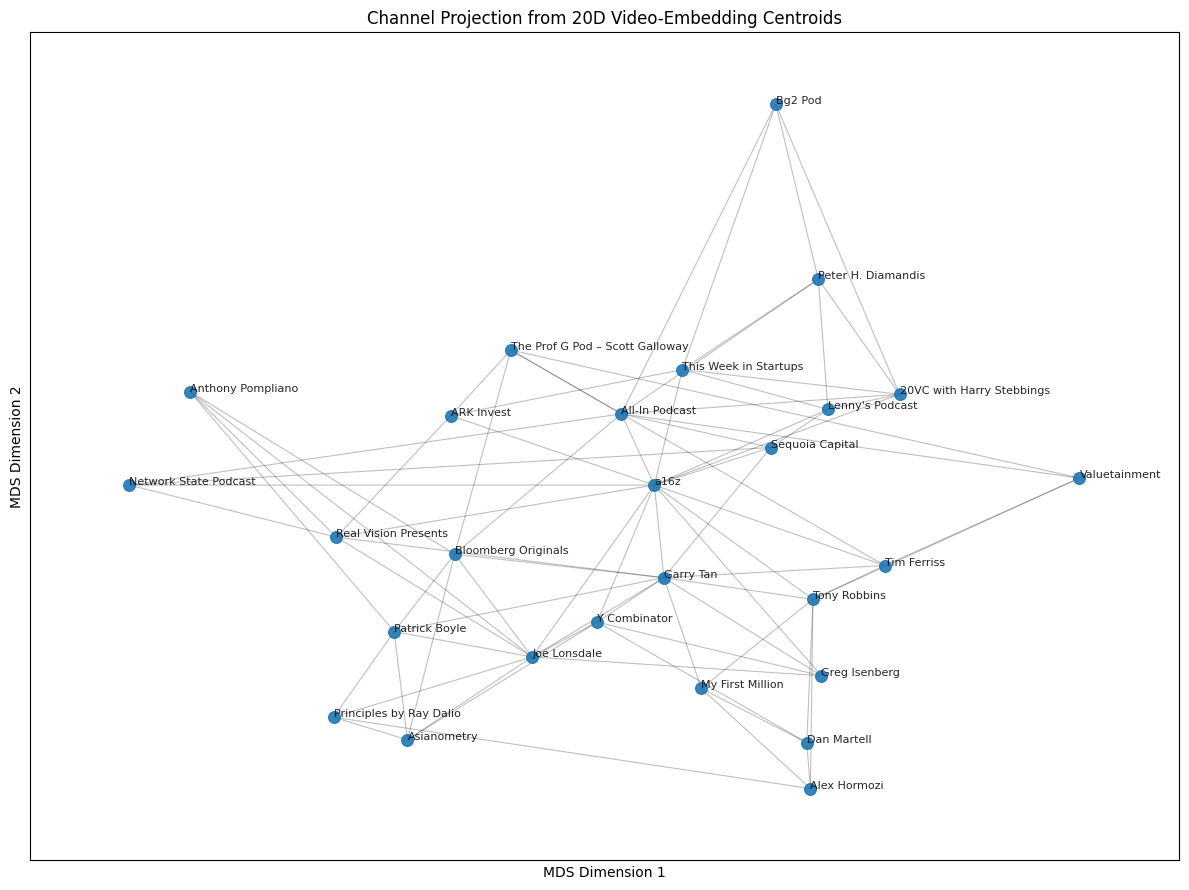

In [8]:
pos = {row.channel_id: (row.x, row.y) for row in projection_df.itertuples(index=False)}

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(G, pos, node_size=70, alpha=0.9)

for row in projection_df.itertuples(index=False):
    plt.text(row.x, row.y, str(row.channel_name), fontsize=8, alpha=0.85)

plt.title('Channel Projection from 20D Video-Embedding Centroids')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.tight_layout()
plt.show()

This cell saves reusable channel-level outputs (centroids, adjacency matrix, and 2D projection) back to Drive for downstream analysis.

In [9]:
out_dir = Path('/content/drive/MyDrive/Graphiko/analysis/graph_projection/latest')
out_dir.mkdir(parents=True, exist_ok=True)

channel_centroids.to_csv(out_dir / 'channel_centroids_20d.csv', index=False)
adjacency_df.to_csv(out_dir / 'channel_adjacency_relative_distance.csv')
projection_df.to_csv(out_dir / 'channel_projection_2d.csv', index=False)

summary = {
    'input_csv': str(EMBEDDINGS_CSV),
    'n_videos': int(len(df)),
    'n_channels': int(len(channel_centroids)),
    'embedding_dimensions': 20,
    'graph_edges': int(G.number_of_edges()),
    'projection_method': 'MDS(metric, precomputed euclidean channel-centroid distance)',
}
(out_dir / 'run_summary.json').write_text(json.dumps(summary, indent=2))

print(f'Saved outputs to: {out_dir}')

Saved outputs to: /content/drive/MyDrive/Graphiko/analysis/graph_projection/latest
